In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Step 1: Define parameters
n_qubits = 32

# Alice generates random bits and bases (0 = Z-basis, 1 = X-basis)
alice_bits = np.random.randint(2, size=n_qubits)
alice_bases = np.random.randint(2, size=n_qubits)

# Bob generates random measurement bases (0 = Z-basis, 1 = X-basis)
bob_bases = np.random.randint(2, size=n_qubits)

# Step 2: Construct and run quantum circuits
circuits = []
for i in range(n_qubits):
    qc = QuantumCircuit(1, 1)
    
    # Alice encodes her bit and basis
    if alice_bits[i] == 1:
        qc.x(0)  # Convert |0> to |1>
    if alice_bases[i] == 1:
        qc.h(0)  # Apply Hadamard for X-basis (+/-)
        
    # Bob measures in his chosen basis
    if bob_bases[i] == 1:
        qc.h(0)  # Apply Hadamard to measure in X-basis
        
    qc.measure(0, 0)
    circuits.append(qc)

# Simulate execution using Qiskit Aer
simulator = AerSimulator()
job = simulator.run(circuits, shots=1)
result = job.result()

# Extract Bob's measurement results
bob_bits = []
for i in range(n_qubits):
    counts = result.get_counts(circuits[i])
    measured_bit = int(list(counts.keys())[0])
    bob_bits.append(measured_bit)

# Step 3: Key Sifting (Keep bits where bases match)
sifted_alice = []
sifted_bob = []

for i in range(n_qubits):
    if alice_bases[i] == bob_bases[i]:
        sifted_alice.append(alice_bits[i])
        sifted_bob.append(bob_bits[i])

print("Alice's original bits:  ", alice_bits)
print("Alice's bases:          ", alice_bases)
print("Bob's bases:            ", bob_bases)
print("Bob's measured bits:    ", bob_bits)
print("Sifted key (Alice):     ", sifted_alice)
print("Sifted key (Bob):       ", sifted_bob)


Alice's original bits:   [0 1 1 0 1 1 0 0 0 1 1 0 1 0 1 1 0 1 1 0 0 0 0 1 0 1 1 0 0 1 1 1]
Alice's bases:           [0 1 1 1 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 0 1 1 1 0 1 0]
Bob's bases:             [0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 1 0 0 1 1 0 1 1 0 1 0 0 1 0 1 0]
Bob's measured bits:     [0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1]
Sifted key (Alice):      [np.int32(0), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(1)]
Sifted key (Bob):        [0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1]


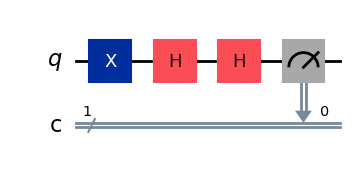

In [6]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1,1)

# Alice encodes bit=1
qc.x(0)

# Alice chooses X basis
qc.h(0)

# Bob measures in X basis
qc.h(0)

qc.measure(0,0)

fig = qc.draw(output='mpl')
display(fig)